In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

In [3]:
	
## Import IRIS dataset
iris=datasets.load_iris()

In [4]:
iris_data=pd.DataFrame(iris.data)


In [5]:
iris_data.columns=iris.feature_names


In [6]:
## Standardization
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [7]:
## Standardization
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [8]:
X_scaled=scaler.fit_transform(iris_data)


In [9]:
## Apply the PCA
from sklearn.decomposition import PCA

In [10]:
pca=PCA(n_components=2)


In [11]:
pca_scaled=pca.fit_transform(X_scaled)


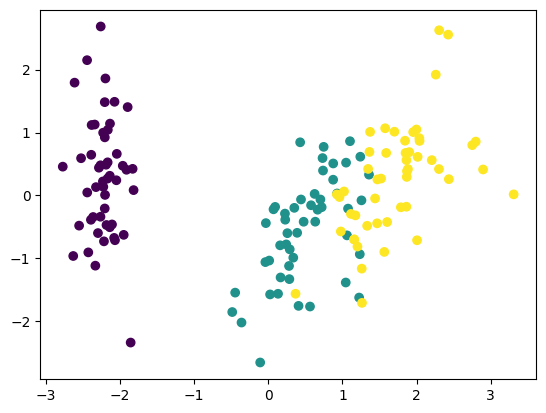

In [12]:
plt.scatter(pca_scaled[:,0],pca_scaled[:,1],c=iris.target)


Text(0, 0.5, 'Eucledian Distance')

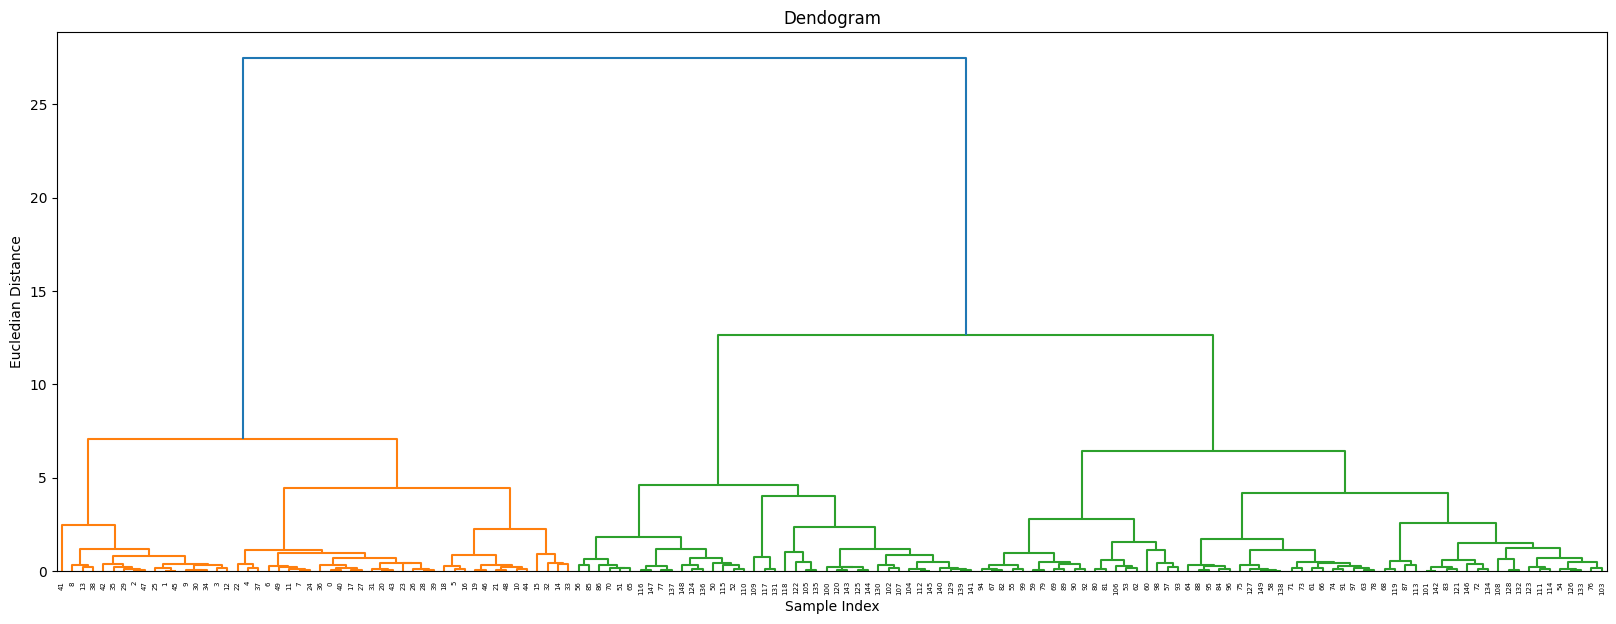

In [13]:
## Agglomerative Clustering
## To construct a dendogram
import scipy.cluster.hierarchy as sc
##plot the dendogram
plt.figure(figsize=(20,7))
plt.title("Dendograms")

## create dendogram
sc.dendrogram(sc.linkage(pca_scaled,method='ward'))
plt.title('Dendogram')
plt.xlabel('Sample Index')
plt.ylabel('Eucledian Distance')

In [17]:
from sklearn.cluster import AgglomerativeClustering

cluster = AgglomerativeClustering(
    n_clusters=2,
    linkage='ward'
)

cluster.fit(pca_scaled)




,n_clusters,2
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


In [ ]:
plt.scatter(pca_scaled[:,0],pca_scaled[:,1],c=cluster.labels_)


In [19]:
## silhouette score
from sklearn.metrics import silhouette_score

In [23]:
silhouette_coefficients = []

# Notice you start at 2 clusters for silhouette coefficient
for k in range(2, 11):
    agglo = AgglomerativeClustering(n_clusters=k,linkage='ward')
    agglo.fit(X_scaled)
    score = silhouette_score(X_scaled, agglo.labels_)
    silhouette_coefficients.append(score)

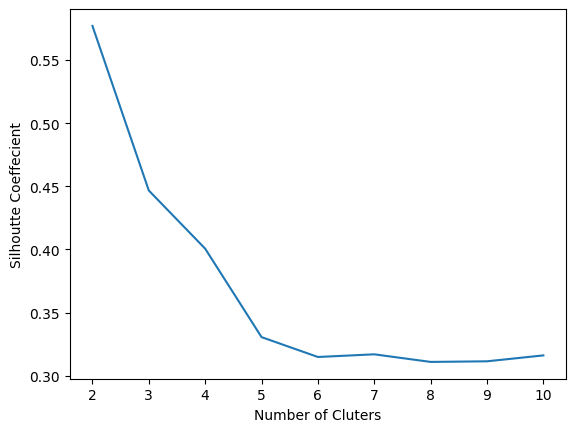

In [24]:
## plotting silhouette score
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Cluters")
plt.ylabel("Silhoutte Coeffecient")
plt.show()
